# 10 · Fusion with missing modalities

**The problem.** In a real clinic, not every patient has every assessment. One has no APOE test, another has had no formal cognitive testing yet. The interface lets a clinician tick what is available, so the model behind it must give a sensible answer for **any combination**.

**Why this is not automatic.** XGBoost can accept missing values, but a model trained on nearly complete records has almost never *seen* a whole section missing. When it meets one, it follows whatever default branch each tree happens to have, and the result can be badly wrong.

**Three approaches compared** (`scripts/train_final.py`), on the same held-out participants:

| Approach | What it is |
|---|---|
| **Standard** | The ordinary model, handed missing values at prediction time |
| **Modality dropout** | The same model, trained on the original data plus four copies in which each optional section was blanked at random with probability 0.35. It has practised with every combination. |
| **Specialist** | A separate model retrained for that exact combination. This is the best that combination can do, so it is the yardstick. It is impractical to deploy: seven combinations here, dozens in general. |

Demographics are always present. The optional sections are APOE, cardiovascular / medical, cognitive tests, and clinical stage (CDR-SB and diagnosis).

In [1]:
import sys, json
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu

nu.set_style()
r = json.loads((nu.REPORTS / "phase6_fusion_results.json").read_text())
pat = r["patterns"]

def table(s):
    rows = {}
    for name, b in pat.items():
        b = b[s]
        rows[name] = {"AUROC specialist": b["specialist"]["auroc"], "AUROC standard": b["standard"]["auroc"], "AUROC dropout": b["dropout"]["auroc"],
                      "Brier specialist": b["specialist"]["brier"], "Brier standard": b["standard"]["brier"], "Brier dropout": b["dropout"]["brier"]}
    return pd.DataFrame(rows).T.round(3)
table("test")

,AUROC specialist,AUROC standard,AUROC dropout,Brier specialist,Brier standard,Brier dropout
Everything,0.937,0.937,0.936,0.066,0.066,0.067
No APOE,0.934,0.935,0.934,0.068,0.068,0.068
No cardiovascular data,0.936,0.934,0.936,0.067,0.067,0.067
No cognitive tests,0.915,0.908,0.915,0.080,0.082,0.077
No clinical stage (CDR),0.922,0.905,0.916,0.074,0.185,0.076
No cognitive assessment at all,0.746,0.611,0.722,0.111,0.441,0.115
Demographics only,0.671,0.593,0.663,0.118,0.444,0.120


In [2]:
table("external")

,AUROC specialist,AUROC standard,AUROC dropout,Brier specialist,Brier standard,Brier dropout
Everything,0.946,0.946,0.947,0.059,0.059,0.059
No APOE,0.945,0.945,0.946,0.060,0.061,0.060
No cardiovascular data,0.945,0.943,0.947,0.060,0.061,0.060
No cognitive tests,0.927,0.925,0.928,0.072,0.074,0.068
No clinical stage (CDR),0.925,0.910,0.925,0.068,0.191,0.070
No cognitive assessment at all,0.744,0.641,0.732,0.106,0.454,0.108
Demographics only,0.674,0.642,0.670,0.111,0.455,0.113


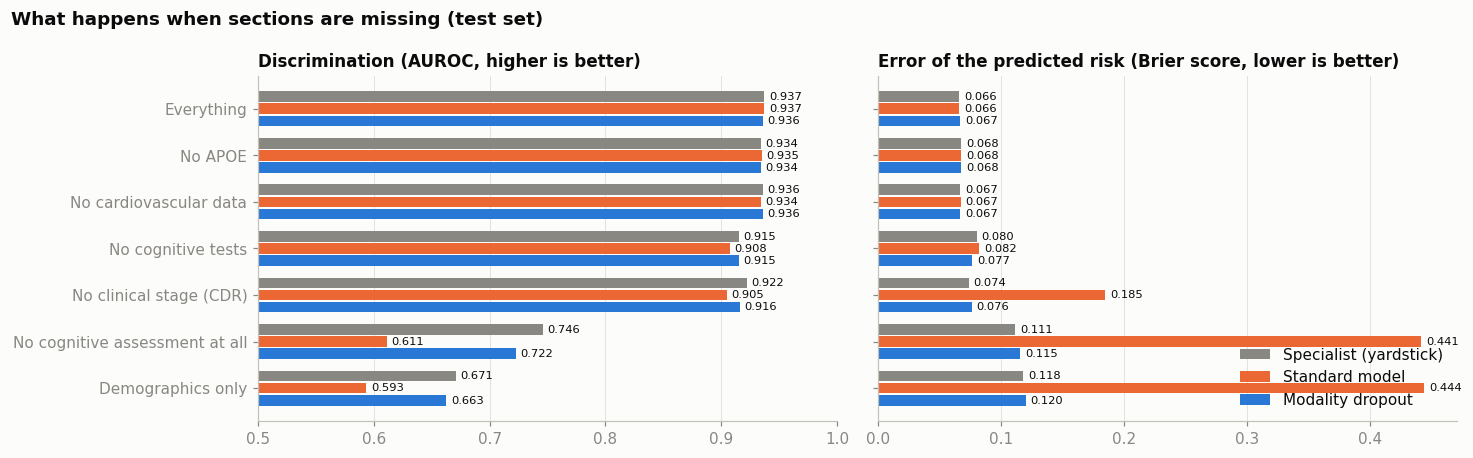

In [3]:
names = list(pat)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
ypos = np.arange(len(names))[::-1]; h = 0.26
for ax, metric, title, xlim in [(axes[0], "auroc", "Discrimination (AUROC, higher is better)", (0.5, 1.0)), (axes[1], "brier", "Error of the predicted risk (Brier score, lower is better)", (0, 0.47))]:
    for i, (kind, color, label) in enumerate([("specialist", nu.MUTED, "Specialist (yardstick)"), ("standard", nu.ORANGE, "Standard model"), ("dropout", nu.BLUE, "Modality dropout")]):
        vals = [pat[n]["test"][kind][metric] for n in names]
        ax.barh(ypos + (1 - i) * h, vals, height=h - 0.03, color=color, label=label)
        for yv, v in zip(ypos, vals): ax.text(v + (0.004 if metric == "auroc" else 0.004), yv + (1 - i) * h, f"{v:.3f}", va="center", fontsize=7.5)
    ax.set_xlim(*xlim); ax.set_title(title); ax.grid(axis="y", visible=False)
axes[0].set_yticks(ypos, names); axes[1].set_yticks(ypos, [""] * len(names)); axes[1].legend(loc="lower right")
fig.suptitle("What happens when sections are missing (test set)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "10_missing_modalities"); plt.show()

## Reading the results

**With everything present, nothing is lost.** The dropout model scores the same as the standard one (AUROC 0.936 against 0.937). Training it to cope with gaps did not cost accuracy on complete records.

**Small sections missing (APOE, cardiovascular):** all three approaches are equal, as expected from notebook 06, where these groups added little.

**Large sections missing: the standard model breaks.**

* With **no cognitive assessment at all**, the standard model's AUROC falls to 0.61 and its Brier score rises to 0.44. A Brier score that high means its risks are badly wrong; always guessing the base rate would score about 0.12. The dropout model reaches 0.72 with a Brier of 0.115, close to the specialist's 0.75 and 0.111.
* With **no clinical stage**, the standard model still ranks people reasonably (0.905) but its Brier is 0.19 against 0.076 for dropout: it ranks well and gives the wrong numbers.
* With **demographics only**, standard 0.59 against dropout 0.66 and specialist 0.67.

**Why the standard model fails so badly.** It learned "CDR-SB is 0 and no MCI" as the route to a low risk. When those inputs are missing, each tree sends the person down a default branch chosen from a handful of training rows, and for many trees that default is the high-risk side. The model then assigns high risk to almost everyone.

**Conclusion.** One model trained with modality dropout gets within about 0.01 to 0.03 AUROC of a purpose-built model for every combination, and its risks stay calibrated. That is the model used in the interface. The remaining gap in the hardest case (0.72 against 0.75) is the price of using one model instead of seven.

The results also show what each kind of information is worth to a clinician. Without any cognitive information the best achievable AUROC is about 0.75; with cognitive tests and clinical stage it is 0.94. The interface says so when those sections are unticked.

## PET as an optional block

PET is added by **late fusion**: the dropout model's clinical risk is combined with the PET measures in a small logistic regression (notebook 08). A person without PET keeps the clinical risk.

In [4]:
pf = r["pet_fusion"]
print("Fusion model fitted on", pf["fitted_on"])
pd.DataFrame({k: {"n": v["n"], "Events": v["events"], "AUROC (95% interval)": f"{v['auroc']:.3f} ({v['auroc_ci'][0]:.3f}-{v['auroc_ci'][1]:.3f})",
                  "Brier": round(v["brier"], 4), "Gain vs clinical only": "reference" if "delta_auroc" not in v else f"{v['delta_auroc']:+.4f} ({v['delta_auroc_ci'][0]:+.4f} to {v['delta_auroc_ci'][1]:+.4f})"}
              for k, v in pf["held_out"].items()}).T

Fusion model fitted on {'n': 284, 'events': 32}


,n,Events,AUROC (95% interval),Brier,Gain vs clinical only
clinical_only,243,33,0.944 (0.887-0.980),0.0549,reference
clinical_plus_pet,243,33,0.964 (0.940-0.983),0.054,+0.0202 (-0.0091 to +0.0659)


The fusion model is fitted on the strict PET design (scan on or before the visit), which leaves only 284 participants and 32 events to fit it and 33 events to test it. The fused estimate scores +0.020 AUROC above the clinical risk on held-out participants, but the interval runs from -0.009 to +0.066, so this is not a demonstrated gain. As in notebook 08, the honest summary is that PET has not been shown to change discrimination here. It stays in the system as an optional input because the design supports it at no cost, and because longer follow-up may change the picture.

## What "fusion" means in this project, and why it is not a deep network

The original idea was a neural network with one branch per modality. The evidence led somewhere simpler:

* the clinical inputs are a table, where gradient boosting matched the deep models (notebook 06);
* PET measures are a handful of numbers for a few hundred people with outcomes, where a small logistic fusion is all the data can support (notebook 08);
* PET images have too few outcome events to learn decline from (notebook 04).

So the fusion that the data supports is: **one tabular model trained with modality dropout, plus small late-fusion blocks for optional modalities**. The idea behind modality dropout comes from the deep multimodal literature and is applied here to a tree model. It is simple, it is tested, and it does what the interface needs.